# Embryo Development Stage Classification — CNN + LSTM (Temporal Sequence Model)

**Assignment 2 — Building on Assignment 1**

| Item | Assignment 1 | Assignment 2 (this notebook) |
|------|-------------|-----------------------------|
| Videos | ~700 | ~300 |
| Model type | Frame-level CNNs (MobileNetV2, VGG16, VGG19, InceptionV3) | CNN feature extractor + LSTM |
| Temporal context | None (each frame classified independently) | Yes — LSTM reads a sliding window of consecutive frames |
| Output | One label per frame | One label per frame **using temporal context** |

**Why LSTM?**  
Embryo development is inherently sequential — stages always progress in a fixed biological order (`tPB2 → tPNa → tPNf → t2 → ... → tHB`). A frame at time `t` is not isolated; it follows frames at `t-1, t-2, ...`. An LSTM can learn to exploit this temporal ordering, making it much harder to predict an "impossible" stage jump.

## 1. Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image, ImageFile

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import time

ImageFile.LOAD_TRUNCATED_IMAGES = True

# ── Paths (same Kaggle dataset as Assignment 1) ────────────────────────────
ROOT_DIR  = "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset"
IMG_DIR   = f"{ROOT_DIR}/embryo_dataset/embryo_dataset"
LABEL_DIR = f"{ROOT_DIR}/embryo_dataset_annotations/embryo_dataset_annotations"

# ── Hyper-parameters ──────────────────────────────────────────────────────
SEQ_LEN   = 16   # consecutive frames fed to LSTM per sample
SEQ_STEP  = 8    # stride of the sliding window (overlap = SEQ_LEN - SEQ_STEP)
BATCH_SZ  = 4    # sequences per batch (each has SEQ_LEN frames → 4×16 = 64 forward passes)
NUM_EPOCHS = 10
BASE_LR    = 1e-3
LSTM_HIDDEN = 256
LSTM_LAYERS = 2
DROPOUT     = 0.3
MAX_VIDEOS  = 300   # cap at 300 as per assignment requirement

compute_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {compute_device}")
print(f"Sequence len: {SEQ_LEN} frames")
print(f"Slide step  : {SEQ_STEP} frames")

Device      : cuda
Sequence len: 16 frames
Slide step  : 8 frames


## 2. Data Indexing — Frame-Level Records

We reuse the same indexing logic from Assignment 1, but **cap at 300 videos** and retain the temporal order of frames within each video.

In [2]:
embryo_folders   = sorted(os.listdir(IMG_DIR))
annotation_files = sorted(os.listdir(LABEL_DIR))

print(f"Total embryo video folders : {len(embryo_folders)}")
print(f"Total annotation CSV files : {len(annotation_files)}")

vid_prefix_map = {}
for vid in embryo_folders:
    frame_files = os.listdir(os.path.join(IMG_DIR, vid))
    if frame_files:
        pfx = frame_files[0].rsplit("_RUN", 1)[0]
        vid_prefix_map[vid] = pfx

record_list = []
skipped_frames = 0
used_vids = 0

for annot_file in tqdm(annotation_files, desc="Indexing annotations"):
    if used_vids >= MAX_VIDEOS:
        break

    vid_name = annot_file.replace("_phases.csv", "")
    frame_dir = os.path.join(IMG_DIR, vid_name)

    if not os.path.exists(frame_dir) or vid_name not in vid_prefix_map:
        continue

    pfx = vid_prefix_map[vid_name]
    raw_df = pd.read_csv(
        os.path.join(LABEL_DIR, annot_file),
        header=None,
        names=["stage", "f_start", "f_end"]
    )

    for _, entry in raw_df.iterrows():
        stage_lbl = str(entry["stage"]).strip()
        idx_start = int(entry["f_start"])
        idx_end   = int(entry["f_end"])

        for fidx in range(idx_start, idx_end + 1):
            fname = f"{pfx}_RUN{fidx}.jpeg"
            fpath = os.path.join(frame_dir, fname)
            if not os.path.exists(fpath):
                skipped_frames += 1
                continue

            record_list.append({
                "video_id"   : vid_name,
                "img_path"   : fpath,
                "frame_num"  : fidx,
                "stage_label": stage_lbl
            })

    used_vids += 1

full_df = pd.DataFrame(record_list)
full_df["stage_label"] = full_df["stage_label"].astype(str).str.strip()
full_df = full_df.sort_values(["video_id", "frame_num"]).reset_index(drop=True)

print(f"\nVideos used           : {used_vids}")
print(f"Total indexed frames  : {len(full_df)}")
print(f"Frames not found      : {skipped_frames}")
print(f"\nStage distribution:\n{full_df['stage_label'].value_counts()}")

Total embryo video folders : 704
Total annotation CSV files : 704


Indexing annotations:   0%|          | 0/704 [00:00<?, ?it/s]


Videos used           : 300
Total indexed frames  : 127441
Frames not found      : 2808

Stage distribution:
stage_label
t9+     21192
tPNa    19126
t8      13046
t2      12609
t4      12546
tEB      7809
tM       7686
tSB      7641
t7       5084
tB       4370
tPB2     3780
t6       3645
t5       3576
tPNf     2944
t3       2387
Name: count, dtype: int64


## 3. Label Encoding

In [3]:
# Chronological stage ordering
DEV_STAGES = [
    'tPB2', 'tPNa', 'tPNf',
    't2',   't3',   't4',   't5',
    't6',   't7',   't8',   't9+',
    'tM',   'tSB',  'tB',   'tEB', 'tHB'
]

stage_encoder = LabelEncoder()

observed_stages = set(full_df["stage_label"].unique())
unknown_stages = sorted(observed_stages - set(DEV_STAGES))
if unknown_stages:
    raise ValueError(f"Labels found in data but not in DEV_STAGES: {unknown_stages}")

# Fit on the full known stage vocabulary, not only on what happened to appear in the subset
stage_encoder.fit(DEV_STAGES)

full_df["class_idx"] = stage_encoder.transform(full_df["stage_label"])
N_CLASSES = len(stage_encoder.classes_)

print("Encoder class order used internally:")
for idx, cls_name in enumerate(stage_encoder.classes_):
    cnt = (full_df["stage_label"] == cls_name).sum()
    print(f"  {idx:2d}: {cls_name:6s}  ({cnt:6d} frames)")

print(f"\nTotal classes: {N_CLASSES}")
print("Chronological order for ordinal loss:")
print(DEV_STAGES)

Encoder class order used internally:
   0: t2      ( 12609 frames)
   1: t3      (  2387 frames)
   2: t4      ( 12546 frames)
   3: t5      (  3576 frames)
   4: t6      (  3645 frames)
   5: t7      (  5084 frames)
   6: t8      ( 13046 frames)
   7: t9+     ( 21192 frames)
   8: tB      (  4370 frames)
   9: tEB     (  7809 frames)
  10: tHB     (     0 frames)
  11: tM      (  7686 frames)
  12: tPB2    (  3780 frames)
  13: tPNa    ( 19126 frames)
  14: tPNf    (  2944 frames)
  15: tSB     (  7641 frames)

Total classes: 16
Chronological order for ordinal loss:
['tPB2', 'tPNa', 'tPNf', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tM', 'tSB', 'tB', 'tEB', 'tHB']


## 4. Train / Val / Test Split  (video-level, no leakage)

In [4]:
all_videos = full_df["video_id"].unique()

train_vids, holdout_vids = train_test_split(all_videos, test_size=0.30, random_state=42)
val_vids,   test_vids    = train_test_split(holdout_vids, test_size=0.50, random_state=42)

train_df = full_df[full_df["video_id"].isin(train_vids)].reset_index(drop=True)
val_df   = full_df[full_df["video_id"].isin(val_vids)].reset_index(drop=True)
test_df  = full_df[full_df["video_id"].isin(test_vids)].reset_index(drop=True)

print(f"Train : {len(train_df):6d} frames  |  {len(train_vids)} videos")
print(f"Val   : {len(val_df):6d} frames  |  {len(val_vids)} videos")
print(f"Test  : {len(test_df):6d} frames  |  {len(test_vids)} videos")

assert len(set(train_vids) & set(val_vids))  == 0
assert len(set(train_vids) & set(test_vids)) == 0
assert len(set(val_vids)   & set(test_vids)) == 0
print("\nLeakage check passed!")

Train :  88774 frames  |  210 videos
Val   :  20262 frames  |  45 videos
Test  :  18405 frames  |  45 videos

Leakage check passed!


## 5. Sequence Dataset

### How the sliding window works

```
Video frames:  F1  F2  F3  F4  F5  F6  F7  F8  F9  F10  F11  F12 ...
               |←── SEQ_LEN=4 ──→|         ← window 1
                       |←── SEQ_LEN=4 ──→|  ← window 2  (stride=2)
```

Each **sample** = `(SEQ_LEN, 3, 224, 224)` image tensor  
Each **label**  = `(SEQ_LEN,)` int tensor — one class per frame  
This is **many-to-many** sequence labeling.

In [5]:
# Image transform (224×224, ImageNet normalisation)
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


class EmbryoSequenceDataset(Dataset):
    """
    Generates sliding-window sequences from a dataframe that
    is already sorted by (video_id, frame_num).

    Each item: (frames_tensor [SEQ_LEN, C, H, W],
                labels_tensor [SEQ_LEN]).

    Windows NEVER cross video boundaries.
    """

    def __init__(self, dataframe, seq_len=SEQ_LEN,
                 step=SEQ_STEP, pipeline=None):
        self.df       = dataframe.reset_index(drop=True)
        self.seq_len  = seq_len
        self.step     = step
        self.pipeline = pipeline
        self.windows  = self._build_windows()

    def _build_windows(self):
        windows = []
        for vid_id, grp in self.df.groupby("video_id", sort=False):
            idxs = grp.index.tolist()
            # Slide over this video's frame indices
            for start in range(0, len(idxs) - self.seq_len + 1, self.step):
                windows.append(idxs[start : start + self.seq_len])
        return windows

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        row_idxs = self.windows[idx]
        frames, labels = [], []

        for ridx in row_idxs:
            row = self.df.iloc[ridx]
            try:
                img = Image.open(row["img_path"]).convert("RGB")
            except Exception:
                img = Image.new("RGB", (224, 224), (0, 0, 0))

            if self.pipeline:
                img = self.pipeline(img)

            frames.append(img)
            labels.append(int(row["class_idx"]))

        frames_tensor = torch.stack(frames, dim=0)      # (SEQ_LEN, C, H, W)
        labels_tensor = torch.tensor(labels, dtype=torch.long)  # (SEQ_LEN,)
        return frames_tensor, labels_tensor


# Build datasets
train_ds = EmbryoSequenceDataset(train_df, pipeline=transform_train)
val_ds   = EmbryoSequenceDataset(val_df,   pipeline=transform_eval)
test_ds  = EmbryoSequenceDataset(test_df,  pipeline=transform_eval)

print(f"Train sequences : {len(train_ds)}")
print(f"Val   sequences : {len(val_ds)}")
print(f"Test  sequences : {len(test_ds)}")

# Quick sanity check
sample_frames, sample_labels = train_ds[0]
print(f"\nSample frames shape : {sample_frames.shape}")
print(f"Sample labels shape : {sample_labels.shape}")
print(f"Sample labels       : {[stage_encoder.classes_[i] for i in sample_labels.tolist()]}")

Train sequences : 10797
Val   sequences : 2469
Test  sequences : 2237

Sample frames shape : torch.Size([16, 3, 224, 224])
Sample labels shape : torch.Size([16])
Sample labels       : [np.str_('tPB2'), np.str_('tPB2'), np.str_('tPB2'), np.str_('tPB2'), np.str_('tPB2'), np.str_('tPB2'), np.str_('tPB2'), np.str_('tPB2'), np.str_('tPB2'), np.str_('tPB2'), np.str_('tPB2'), np.str_('tPB2'), np.str_('tPB2'), np.str_('tPB2'), np.str_('tPB2'), np.str_('tPB2')]


In [6]:
USE_PIN  = compute_device.type == "cuda"
N_WORKERS = 2 if compute_device.type == "cuda" else 0

loader_train = DataLoader(train_ds, batch_size=BATCH_SZ, shuffle=True,
                          num_workers=N_WORKERS, pin_memory=USE_PIN)
loader_val   = DataLoader(val_ds,   batch_size=BATCH_SZ, shuffle=False,
                          num_workers=N_WORKERS, pin_memory=USE_PIN)
loader_test  = DataLoader(test_ds,  batch_size=BATCH_SZ, shuffle=False,
                          num_workers=N_WORKERS, pin_memory=USE_PIN)

chk_frames, chk_labels = next(iter(loader_train))
print(f"Batch frames shape : {chk_frames.shape}")
print(f"Batch labels shape : {chk_labels.shape}")
# Expected: (BATCH_SZ, SEQ_LEN, C, H, W) and (BATCH_SZ, SEQ_LEN)

Batch frames shape : torch.Size([4, 16, 3, 224, 224])
Batch labels shape : torch.Size([4, 16])


## 6. Model — CNN Feature Extractor + Bidirectional LSTM

### Architecture overview

```
Input: (B, T, 3, 224, 224)
          │
          ▼  [shared MobileNetV2 — frozen backbone]
CNN features: (B, T, 1280)          ← per-frame embedding
          │
          ▼  [projection layer]
Projected:  (B, T, 512)
          │
          ▼  [Bidirectional LSTM  ×  2 layers]
LSTM out:   (B, T, 2 × LSTM_HIDDEN)  ← reads past AND future frames
          │
          ▼  [Dropout + Linear classifier]
Logits:     (B, T, N_CLASSES)        ← prediction for EVERY frame
```

**Why Bidirectional?**  
During training we have the full sequence. BiLSTM lets each frame see *both* past frames (is the embryo dividing?) and future frames (did division complete?), giving richer context for ambiguous frames.

In [7]:
class CNN_LSTM_Classifier(nn.Module):
    def __init__(self, n_classes, lstm_hidden=256, lstm_layers=2, dropout=0.3, bidirectional=True):
        super().__init__()

        backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        cnn_out_dim = 1280

        for p in self.cnn.parameters():
            p.requires_grad = False

        self.proj = nn.Sequential(
            nn.Linear(cnn_out_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout)
        )

        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(lstm_out_dim, n_classes)
        )

        n_cnn   = sum(p.numel() for p in self.cnn.parameters())
        n_train = sum(p.numel() for p in self.parameters() if p.requires_grad)
        n_total = sum(p.numel() for p in self.parameters())
        print(f"CNN params (frozen) : {n_cnn:,}")
        print(f"Trainable params    : {n_train:,}  /  {n_total:,} total")

    def extract_features(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)

        # Only skip gradient tracking when the CNN is fully frozen
        cnn_trainable = any(p.requires_grad for p in self.cnn.parameters())
        if cnn_trainable:
            feats = self.cnn(x)
        else:
            with torch.no_grad():
                feats = self.cnn(x)

        feats = self.pool(feats)
        feats = feats.view(B * T, -1)
        feats = self.proj(feats)
        feats = feats.view(B, T, 512)
        return feats

    def forward(self, x):
        feats = self.extract_features(x)
        lstm_out, _ = self.lstm(feats)
        logits = self.classifier(lstm_out)
        return logits

## 7. Loss Function — Biologically-Aware Ordinal Loss (reused from Assignment 1)

In [8]:
def stage_position_tensor(encoder, ordered_stages, device):
    pos_vec = torch.zeros(len(encoder.classes_), device=device, dtype=torch.float32)
    stage_to_rank = {stage_name: rank for rank, stage_name in enumerate(ordered_stages)}

    missing = [stage for stage in ordered_stages if stage not in encoder.classes_]
    if missing:
        raise ValueError(f"These stages are missing from the encoder: {missing}")

    for class_idx, cls_name in enumerate(encoder.classes_):
        pos_vec[class_idx] = float(stage_to_rank[cls_name])

    return pos_vec


class DevStageLoss(nn.Module):
    def __init__(self, encoder, ordered_stages, alpha=0.1, device='cpu'):
        super().__init__()
        self.alpha = alpha
        self.register_buffer('stage_pos', stage_position_tensor(encoder, ordered_stages, device))

    def forward(self, logits, targets):
        B, T, C = logits.shape

        logits_flat  = logits.reshape(B * T, C)
        targets_flat = targets.reshape(B * T).long()   # 🔥 IMPORTANT

        # Safety check
        if (targets_flat < 0).any() or (targets_flat >= C).any():
            raise ValueError("Invalid target index detected")

        loss_ce = F.cross_entropy(logits_flat, targets_flat)

        probs = F.softmax(logits_flat, dim=1)
        gt_pos = self.stage_pos[targets_flat]
        pred_pos = (probs * self.stage_pos.unsqueeze(0)).sum(dim=1)

        loss_ord = torch.abs(pred_pos - gt_pos).mean()

        total = loss_ce + self.alpha * loss_ord
        return total, loss_ce.item(), loss_ord.item()


loss_fn = DevStageLoss(
    encoder=stage_encoder,
    ordered_stages=DEV_STAGES,
    alpha=0.1,
    device=compute_device
).to(compute_device)

print("Loss function ready.")
print("Ordinal ranks used by the loss:")
print({stage: rank for rank, stage in enumerate(DEV_STAGES)})

Loss function ready.
Ordinal ranks used by the loss:
{'tPB2': 0, 'tPNa': 1, 'tPNf': 2, 't2': 3, 't3': 4, 't4': 5, 't5': 6, 't6': 7, 't7': 8, 't8': 9, 't9+': 10, 'tM': 11, 'tSB': 12, 'tB': 13, 'tEB': 14, 'tHB': 15}


## 8. Training & Evaluation Loops

In [9]:
def run_train_epoch(model, loader, optimizer, criterion, device,
                    ep=0, total_ep=10):
    model.train()
    cum_loss = cum_ce = cum_ord = n_correct = n_total = 0

    bar = tqdm(loader, desc=f"Ep {ep+1}/{total_ep} TRAIN", leave=False)
    for frames, labels in bar:
        frames = frames.to(device)   # (B, T, C, H, W)
        labels = labels.to(device)   # (B, T)

        optimizer.zero_grad()
        logits = model(frames)       # (B, T, N_CLASSES)
        loss, lce, lord = criterion(logits, labels)
        loss.backward()
        # Gradient clipping — important for RNNs
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        # Frame-level accuracy
        preds     = logits.argmax(dim=-1)           # (B, T)
        n_correct += (preds == labels).sum().item()
        n_total   += labels.numel()
        cum_loss  += loss.item()
        cum_ce    += lce
        cum_ord   += lord

        bar.set_postfix(
            loss=f"{cum_loss/max(bar.n,1):.4f}",
            ce  =f"{cum_ce/max(bar.n,1):.4f}",
            acc =f"{n_correct/n_total:.4f}"
        )

    nb = len(loader)
    return cum_loss/nb, cum_ce/nb, cum_ord/nb, n_correct/n_total


def run_eval(model, loader, criterion, device, phase="VAL"):
    model.eval()
    cum_loss = cum_ce = cum_ord = n_correct = n_total = 0
    pred_buf, true_buf = [], []

    bar = tqdm(loader, desc=f"{phase}", leave=False)
    with torch.no_grad():
        for frames, labels in bar:
            frames = frames.to(device)
            labels = labels.to(device)

            logits = model(frames)
            loss, lce, lord = criterion(logits, labels)

            preds     = logits.argmax(dim=-1)
            n_correct += (preds == labels).sum().item()
            n_total   += labels.numel()
            cum_loss  += loss.item()
            cum_ce    += lce
            cum_ord   += lord

            pred_buf.extend(preds.view(-1).cpu().numpy())
            true_buf.extend(labels.view(-1).cpu().numpy())

            bar.set_postfix(
                loss=f"{cum_loss/max(bar.n,1):.4f}",
                acc =f"{n_correct/n_total:.4f}"
            )

    nb = len(loader)
    return (cum_loss/nb, cum_ce/nb, cum_ord/nb,
            n_correct/n_total, pred_buf, true_buf)

## 9. Training — Phase 1 (LSTM head only) → Phase 2 (fine-tune CNN)

In [10]:
batch = next(iter(loader_train))
x, y = batch
print("logits class count expected:", len(stage_encoder.classes_))
print("target min:", y.min().item())
print("target max:", y.max().item())
print("unique targets:", torch.unique(y)[:30])

logits class count expected: 16
target min: 4
target max: 13
unique targets: tensor([ 4,  7,  9, 13])


In [12]:
model = CNN_LSTM_Classifier(
    n_classes=N_CLASSES,
    lstm_hidden=LSTM_HIDDEN,
    lstm_layers=LSTM_LAYERS,
    dropout=DROPOUT,
    bidirectional=True
).to(compute_device)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 108MB/s] 


CNN params (frozen) : 2,223,872
Trainable params    : 3,819,024  /  6,042,896 total


In [12]:
# ── Optimizer: only LSTM + projection + classifier (CNN frozen) ────────────
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=BASE_LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-5
)

history = {k: [] for k in [
    "tr_loss", "vl_loss", "tr_acc", "vl_acc",
    "tr_ce", "vl_ce", "tr_ord", "vl_ord"
]}

best_val_acc = 0.0
ckpt_path    = "/kaggle/working/cnn_lstm_best.pth"

print("=" * 60)
print("  Phase 1: Training LSTM head (CNN backbone frozen)")
print("=" * 60)

for ep in range(NUM_EPOCHS):
    t0 = time.time()

    tr_loss, tr_ce, tr_ord, tr_acc = run_train_epoch(
        model, loader_train, optimizer, loss_fn, compute_device, ep, NUM_EPOCHS
    )
    vl_loss, vl_ce, vl_ord, vl_acc, _, _ = run_eval(
        model, loader_val, loss_fn, compute_device, "VAL"
    )
    scheduler.step()

    for k, v in [("tr_loss", tr_loss), ("vl_loss", vl_loss),
                 ("tr_acc",  tr_acc),  ("vl_acc",  vl_acc),
                 ("tr_ce",   tr_ce),   ("vl_ce",   vl_ce),
                 ("tr_ord",  tr_ord),  ("vl_ord",  vl_ord)]:
        history[k].append(v)

    flag = ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), ckpt_path)
        flag = "  ✓ saved"

    print(f"  Ep {ep+1:02d}/{NUM_EPOCHS} | "
          f"tr_acc={tr_acc:.4f}  vl_acc={vl_acc:.4f} | "
          f"vl_loss={vl_loss:.4f} | {time.time()-t0:.0f}s{flag}")

print(f"\nBest val accuracy (Phase 1): {best_val_acc:.4f}")

  Phase 1: Training LSTM head (CNN backbone frozen)


Ep 1/10 TRAIN:   0%|          | 0/2700 [00:00<?, ?it/s]

VAL:   0%|          | 0/618 [00:00<?, ?it/s]

  Ep 01/10 | tr_acc=0.3353  vl_acc=0.4186 | vl_loss=1.9153 | 1246s  ✓ saved


Ep 2/10 TRAIN:   0%|          | 0/2700 [00:00<?, ?it/s]

...

VAL:   0%|          | 0/618 [00:00<?, ?it/s]

  Ep 09/10 | tr_acc=0.5597  vl_acc=0.5035 | vl_loss=1.9646 | 907s  ✓ saved


Ep 10/10 TRAIN:   0%|          | 0/2700 [00:00<?, ?it/s]

VAL:   0%|          | 0/618 [00:00<?, ?it/s]

  Ep 10/10 | tr_acc=0.5671  vl_acc=0.4944 | vl_loss=1.9542 | 856s

Best val accuracy (Phase 1): 0.5035


In [13]:
# Load best Phase 1 model before fine-tuning
model.load_state_dict(torch.load(ckpt_path, map_location=compute_device))
model.to(compute_device)

print("=" * 60)
print("  Phase 2: Fine-tuning CNN last 3 blocks + LSTM")
print("=" * 60)

# Unfreeze last CNN blocks safely
for i, layer in enumerate(model.cnn):
    if i >= 16:
        for param in layer.parameters():
            param.requires_grad = True

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params after unfreeze: {n_trainable:,}")

# Reset best score for phase 2
best_val_acc = 0.0

FT_EPOCHS = 5
ft_optimizer = torch.optim.AdamW([
    {"params": model.cnn.parameters(), "lr": BASE_LR * 0.01},
    {"params": model.proj.parameters(), "lr": BASE_LR * 0.1},
    {"params": model.lstm.parameters(), "lr": BASE_LR * 0.1},
    {"params": model.classifier.parameters(), "lr": BASE_LR * 0.1},
], weight_decay=1e-4)

ft_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    ft_optimizer, T_max=FT_EPOCHS, eta_min=1e-6
)

for ep in range(FT_EPOCHS):
    t0 = time.time()

    tr_loss, tr_ce, tr_ord, tr_acc = run_train_epoch(
        model, loader_train, ft_optimizer, loss_fn, compute_device, ep, FT_EPOCHS
    )
    vl_loss, vl_ce, vl_ord, vl_acc, _, _ = run_eval(
        model, loader_val, loss_fn, compute_device, "VAL"
    )
    ft_scheduler.step()

    flag = ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), ckpt_path)
        flag = "  ✓ saved"

    print(f"  FT Ep {ep+1:02d}/{FT_EPOCHS} | "
          f"tr_acc={tr_acc:.4f}  vl_acc={vl_acc:.4f} | "
          f"vl_loss={vl_loss:.4f} | {time.time()-t0:.0f}s{flag}")

print(f"\nBest val accuracy (overall): {best_val_acc:.4f}")

  Phase 2: Fine-tuning CNN last 3 blocks + LSTM
Trainable params after unfreeze: 5,025,104


Ep 1/5 TRAIN:   0%|          | 0/2700 [00:00<?, ?it/s]

VAL:   0%|          | 0/618 [00:00<?, ?it/s]

  FT Ep 01/5 | tr_acc=0.5673  vl_acc=0.4817 | vl_loss=2.0827 | 904s  ✓ saved


Ep 2/5 TRAIN:   0%|          | 0/2700 [00:00<?, ?it/s]

...

VAL:   0%|          | 0/618 [00:00<?, ?it/s]

  FT Ep 04/5 | tr_acc=0.6265  vl_acc=0.5100 | vl_loss=2.0910 | 839s  ✓ saved


Ep 5/5 TRAIN:   0%|          | 0/2700 [00:00<?, ?it/s]

VAL:   0%|          | 0/618 [00:00<?, ?it/s]

  FT Ep 05/5 | tr_acc=0.6374  vl_acc=0.5108 | vl_loss=2.1522 | 894s  ✓ saved

Best val accuracy (overall): 0.5108


## 10. Test Set Evaluation

In [13]:
# Load best checkpoint
ckpt_path = "/kaggle/input/datasets/kaustubhdeshmukh1111/model/cnn_lstm_best.pth"
model.load_state_dict(torch.load(ckpt_path, map_location=compute_device))
model.to(compute_device)
model.eval()
print(f"Loaded best checkpoint from: {ckpt_path}")

test_loss, test_ce, test_ord, test_acc, preds, gt = run_eval(
    model, loader_test, loss_fn, compute_device, "TEST"
)

print(f"\nTest Loss : {test_loss:.4f}")
print(f"Test CE   : {test_ce:.4f}")
print(f"Test Ord  : {test_ord:.4f}")
print(f"Test Acc  : {test_acc:.4f}  ({test_acc*100:.2f}%)")

all_labels = list(range(len(stage_encoder.classes_)))

print("\nPer-class report:")
print(classification_report(
    gt,
    preds,
    labels=all_labels,
    target_names=stage_encoder.classes_,
    zero_division=0
))

Loaded best checkpoint from: /kaggle/input/datasets/kaustubhdeshmukh1111/model/cnn_lstm_best.pth


TEST:   0%|          | 0/560 [00:00<?, ?it/s]


Test Loss : 1.6413
Test CE   : 1.5442
Test Ord  : 0.9711
Test Acc  : 0.5366  (53.66%)

Per-class report:
              precision    recall  f1-score   support

          t2       0.69      0.55      0.61      3808
          t3       0.17      0.00      0.00       518
          t4       0.45      0.58      0.51      3673
          t5       0.00      0.00      0.00      1162
          t6       0.05      0.03      0.04       486
          t7       0.16      0.01      0.02      1451
          t8       0.35      0.36      0.36      3944
         t9+       0.54      0.72      0.62      6373
          tB       0.33      0.29      0.31      1208
         tEB       0.48      0.56      0.52      1726
         tHB       0.00      0.00      0.00         0
          tM       0.46      0.48      0.47      2119
        tPB2       0.46      0.64      0.54       910
        tPNa       0.84      0.81      0.83      5636
        tPNf       0.73      0.58      0.65       866
         tSB       0.39      

## 11. Visualisations

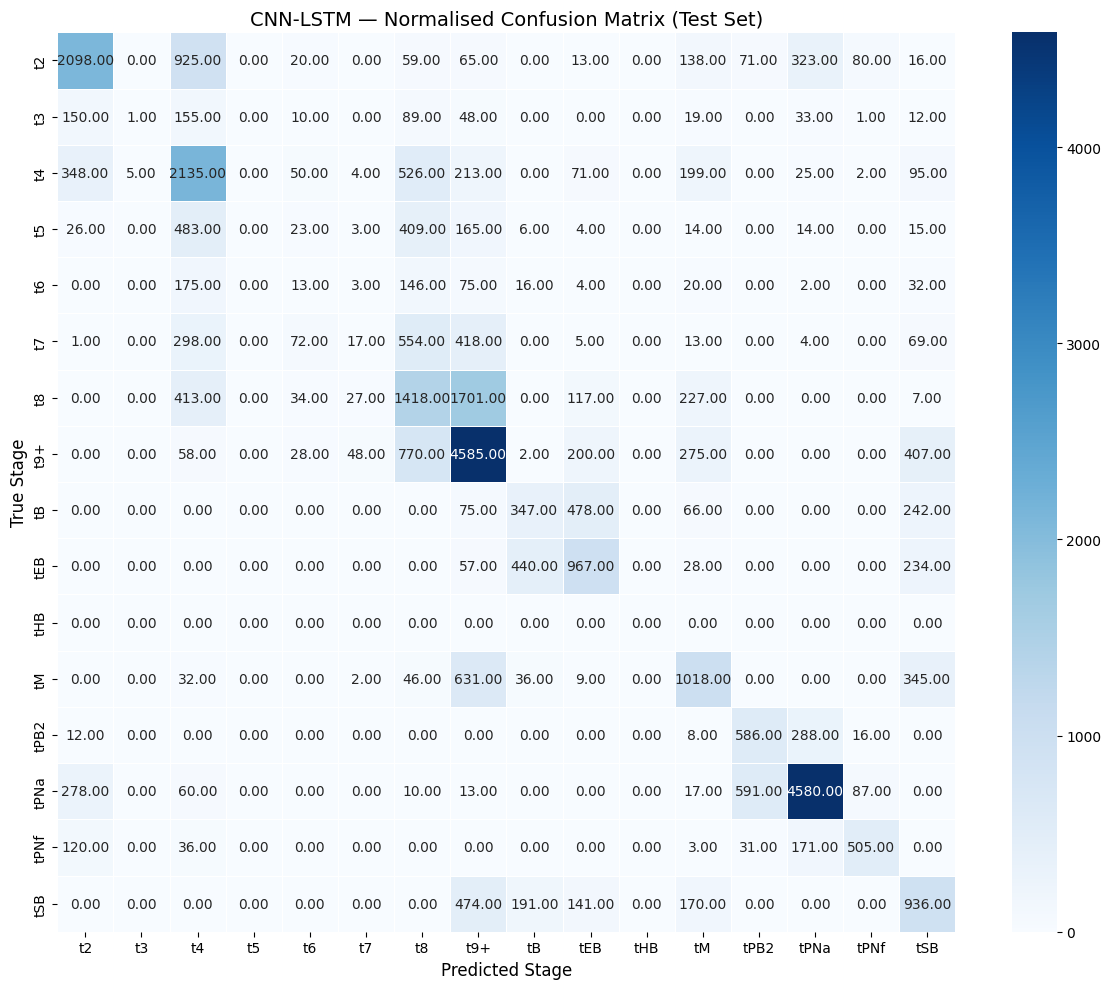

Saved: lstm_confusion_matrix.png


In [15]:
# ── Confusion matrix ────────────────────────────────────────────────────────
cm = confusion_matrix(gt, preds, labels=all_labels)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt=".2f",
    xticklabels=stage_encoder.classes_,
    yticklabels=stage_encoder.classes_,
    cmap="Blues", linewidths=0.4,
    ax=ax
)
ax.set_xlabel("Predicted Stage", fontsize=12)
ax.set_ylabel("True Stage",      fontsize=12)
ax.set_title("CNN-LSTM — Normalised Confusion Matrix (Test Set)", fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/lstm_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lstm_confusion_matrix.png")

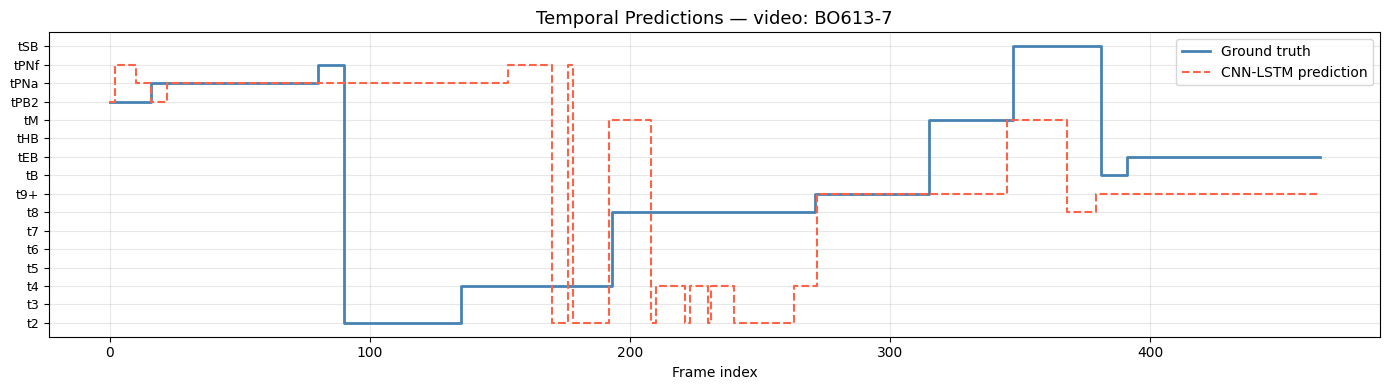

Saved: lstm_temporal_plot.png


In [16]:
# ── Temporal prediction plot for one test video ────────────────────────────
# Pick the first test video and predict stage-by-stage

sample_vid = test_vids[0]
vid_frames = test_df[test_df["video_id"] == sample_vid].sort_values("frame_num")

vid_preds  = []
vid_gt     = vid_frames["class_idx"].tolist()
n_frames   = len(vid_frames)

model.eval()
with torch.no_grad():
    for start in range(0, n_frames - SEQ_LEN + 1, SEQ_STEP):
        window = vid_frames.iloc[start : start + SEQ_LEN]
        imgs   = []
        for _, row in window.iterrows():
            try:
                img = Image.open(row["img_path"]).convert("RGB")
            except Exception:
                img = Image.new("RGB", (224, 224), (0, 0, 0))
            imgs.append(transform_eval(img))

        t = torch.stack(imgs, dim=0).unsqueeze(0).to(compute_device)
        logits = model(t)   # (1, T, N_CLASSES)
        p = logits.argmax(dim=-1).squeeze(0).cpu().tolist()  # (T,)
        vid_preds.extend(p)

# Trim to same length as ground truth (sliding window may overlap)
min_len = min(len(vid_preds), len(vid_gt))
vid_preds = vid_preds[:min_len]
vid_gt    = vid_gt[:min_len]

fig, ax = plt.subplots(figsize=(14, 4))
ax.step(range(min_len), vid_gt,   where="post", color="steelblue",
        linewidth=2,   label="Ground truth")
ax.step(range(min_len), vid_preds, where="post", color="tomato",
        linewidth=1.5, linestyle="--", label="CNN-LSTM prediction")
ax.set_yticks(range(N_CLASSES))
ax.set_yticklabels(stage_encoder.classes_, fontsize=9)
ax.set_xlabel("Frame index")
ax.set_title(f"Temporal Predictions — video: {sample_vid}", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/lstm_temporal_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lstm_temporal_plot.png")

## 12. Summary Table

In [18]:
summary = pd.DataFrame([{
    "Model"         : "CNN (MobileNetV2) + BiLSTM",
    "Videos used"   : used_vids,
    "Seq length (T)": SEQ_LEN,
    "LSTM hidden"   : LSTM_HIDDEN,
    "LSTM layers"   : LSTM_LAYERS,
    "Bidirectional" : "Yes",
    "Test Acc"      : f"{test_acc * 100:.2f}%",
    "Test CE Loss"  : f"{test_ce:.4f}",
    "Test Ord Loss" : f"{test_ord:.4f}",
}])

print(summary.T.to_string(header=False))
summary.to_csv("/kaggle/working/lstm_summary.csv", index=False)
print("\nSaved: lstm_summary.csv")

Model           CNN (MobileNetV2) + BiLSTM
Videos used                            300
Seq length (T)                          16
LSTM hidden                            256
LSTM layers                              2
Bidirectional                          Yes
Test Acc                            53.66%
Test CE Loss                        1.5442
Test Ord Loss                       0.9711

Saved: lstm_summary.csv


## 13. Architecture Discussion — What Changed from Assignment 1?

| Aspect | Assignment 1 (CNN only) | Assignment 2 (CNN + LSTM) |
|--------|------------------------|---------------------------|
| **Input per sample** | Single frame `(3, 224, 224)` | Sequence of T frames `(T, 3, 224, 224)` |
| **Temporal context** | None | BiLSTM reads T=16 frames bidirectionally |
| **Dataset** | Frame-level `Dataset` | Sliding-window `EmbryoSequenceDataset` |
| **Loss shape** | `(B, N_CLASSES)` vs `(B,)` | `(B, T, N_CLASSES)` vs `(B, T)` |
| **Gradient clipping** | Not needed | Essential for RNN stability (`max_norm=5.0`) |
| **Videos** | ~700 | 300 |

### Why does the LSTM help?
1. **Monotonic transitions**: An embryo NEVER goes from `tB` back to `t2`. The LSTM learns to suppress biologically impossible predictions.  
2. **Ambiguous frames**: Frames at stage boundaries are hard to classify individually. The LSTM uses neighbouring frames as "votes" to resolve ambiguity.  
3. **Duration modelling**: Some stages last hundreds of frames, others only a few. The LSTM builds an implicit timer over the sequence.

### Possible extensions
- **GRU** instead of LSTM (fewer parameters, often similar accuracy)  
- **Transformer encoder** over frame embeddings (self-attention instead of recurrence)  
- **CRF** on top of LSTM output to enforce stage ordering hard constraints  
- **Pre-extract CNN features** to disk to avoid re-computing them every epoch